# Spaceship Titanic — Binary Classification

Real Kaggle competition data (see `data/spaceship_titanic/README.md`): 8693
training passengers, target `Transported` (bool), a well-balanced ~50.4%/49.6%
split. This notebook demonstrates:

- Full EDA (alerts, recommendations, target correlations, rule-tree feature
  importances) on a mixed numeric/categorical/string dataset.
- Deterministic **pre-split** feature engineering from structured string
  columns: `PassengerId` ("`gggg_pp`") -> travel-group id, `Cabin`
  ("`deck/num/side`") -> `Deck`/`CabinNum`/`Side`, plus an engineered
  `TotalSpend` (sum of the 5 spending columns) and a `CryoSleep`-vs-spend
  consistency signal.
- A leakage-safe pipeline: `TrainTestSplitter` -> `SimpleImputer` ->
  `OneHotEncoder` -> `StandardScaler`.
- Model comparison: baseline Logistic Regression vs. tuned Random Forest vs.
  a voting ensemble.

Polars + numpy only — no pandas.

In [1]:
import numpy as np
import polars as pl

from skyulf import SkyulfPipeline
from skyulf.profiling.analyzer import EDAAnalyzer
from skyulf.profiling.visualizer import EDAVisualizer

train = pl.read_csv("data/spaceship_titanic/train.csv", infer_schema_length=None)
print(train.shape)
train.head(3)

(8693, 14)


PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
str,str,bool,str,str,f64,bool,f64,f64,f64,f64,f64,str,bool
"""0001_01""","""Europa""",false,"""B/0/P""","""TRAPPIST-1e""",39.0,false,0.0,0.0,0.0,0.0,0.0,"""Maham Ofracculy""",false
"""0002_01""","""Earth""",false,"""F/0/S""","""TRAPPIST-1e""",24.0,false,109.0,9.0,25.0,549.0,44.0,"""Juanna Vines""",true
"""0003_01""","""Europa""",false,"""A/0/S""","""TRAPPIST-1e""",58.0,true,43.0,3576.0,0.0,6715.0,49.0,"""Altark Susent""",false


## 1. Full EDA

In [2]:
profile = EDAAnalyzer(train.drop("PassengerId", "Name")).analyze(target_col="Transported")

print(f"Rows: {profile.row_count}  Missing cells: {profile.missing_cells_percentage:.2f}%")
print(f"Alerts ({len(profile.alerts)} total), first 8:")
for a in profile.alerts[:8]:
    print(" -", a.message)

Rows: 8693  Missing cells: 2.04%
Alerts (6 total), first 8:
 - Column 'Age' contains significant outliers.
 - Column 'RoomService' contains significant outliers.
 - Column 'FoodCourt' contains significant outliers.
 - Column 'ShoppingMall' contains significant outliers.
 - Column 'Spa' contains significant outliers.
 - Column 'VRDeck' contains significant outliers.


In [3]:
print("Top recommendations:")
for r in profile.recommendations[:6]:
    print(" -", r.message if hasattr(r, "message") else r)

Top recommendations:
 - column='HomePlanet' action='Impute' reason='Missing values (2.3%)' suggestion="Impute 'HomePlanet' using Mode."
 - column='CryoSleep' action='Impute' reason='Missing values (2.5%)' suggestion="Impute 'CryoSleep' using Mode."
 - column='Cabin' action='Impute' reason='Missing values (2.3%)' suggestion="Impute 'Cabin' using Mode."
 - column='Destination' action='Impute' reason='Missing values (2.1%)' suggestion="Impute 'Destination' using Mode."
 - column='Age' action='Impute' reason='Missing values (2.1%)' suggestion="Impute 'Age' using Median."
 - column='VIP' action='Impute' reason='Missing values (2.3%)' suggestion="Impute 'VIP' using Mode."


In [4]:
rule_tree = profile.rule_tree
if rule_tree and rule_tree.feature_importances:
    top = sorted(rule_tree.feature_importances, key=lambda d: -d["importance"])[:8]
    print("Top rule-tree feature importances:")
    for f in top:
        print(f"  {f['feature']:20s} {f['importance']:.4f}")

Top rule-tree feature importances:
  RoomService          0.4169
  VRDeck               0.3366
  Spa                  0.1719
  FoodCourt            0.0615
  Age                  0.0067
  ShoppingMall         0.0064


In [5]:
EDAVisualizer(profile, train.drop("PassengerId", "Name")).summary()

╭────────────────────╮
│ Skyulf EDA Summary │
╰────────────────────╯

1. Data Quality

┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Metric         ┃ Value              ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ Rows           │ 8693               │
│ Columns        │ 12                 │
│ Missing Cells  │ 2.036121016910158% │
│ Duplicate Rows │ 30                 │
│ Target Column  │ Transported        │
│ Task Type      │ Classification     │
└────────────────┴────────────────────┘

2. Numeric Statistics

┏━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ Column       ┃   Mean ┃     Std ┃  Min ┃      Max ┃  Skew ┃   Kurt ┃ Normality ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ Age          │  28.83 │   14.49 │ 0.00 │    79.00 │  0.42 │   0.10 │    No     │
│ RoomService  │ 224.69 │  666.72 │ 0.00 │ 14327.00 │  6.33 │  65.23 │    No     │
│ FoodCourt    │ 458.08 │ 1611.49 │ 0.00 │ 29813.00 │  7.10 │  73.26 │    No     │
│ ShoppingMall │ 173.73 │  604.70 │ 0.00 │ 23492.00 │ 12.63 │ 328.68 │    No     │
│ Spa          │ 311.14 │ 1136.71 │ 0.00 │ 22408.00 │  7.63 │  81.15 │    No     │
│ VRDeck       │ 304.85 │ 1145.72 │ 0.00 │ 24133.00 │  7.82 │  85.96 │    No     │
└──────────────┴────────┴─────────┴──────┴──────────┴───────┴────────┴───────────┘

...

• Column 'RoomService' contains significant outliers.

• Column 'FoodCourt' contains significant outliers.

• Column 'ShoppingMall' contains significant outliers.

• Column 'Spa' contains significant outliers.

• Column 'VRDeck' contains significant outliers.

/Users/BH7043/Skyulf/.venv/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(


Displaying plots...


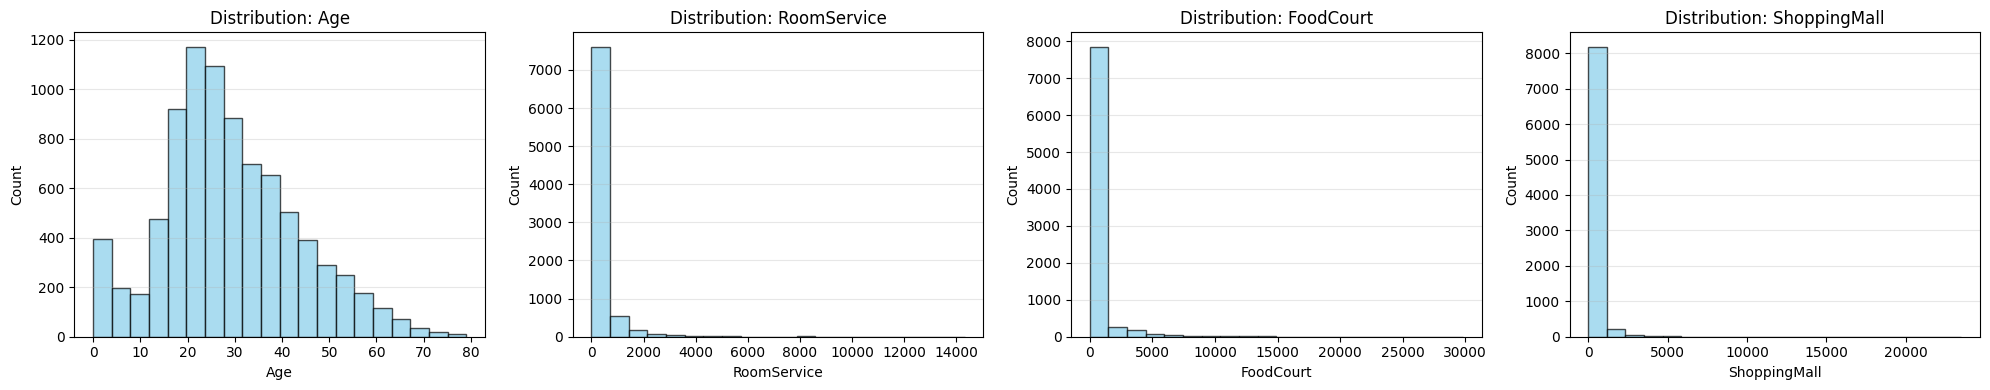

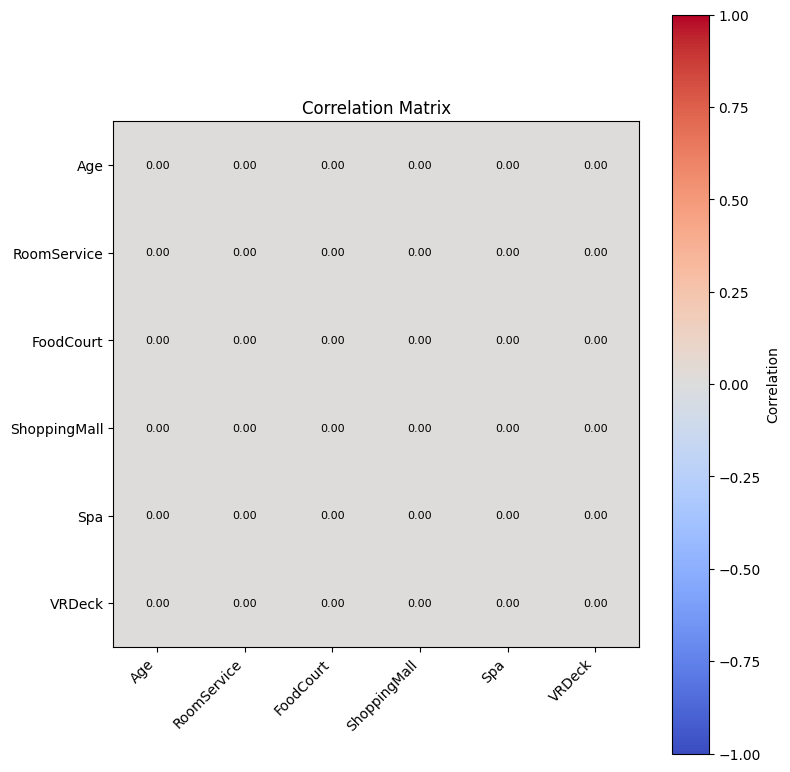

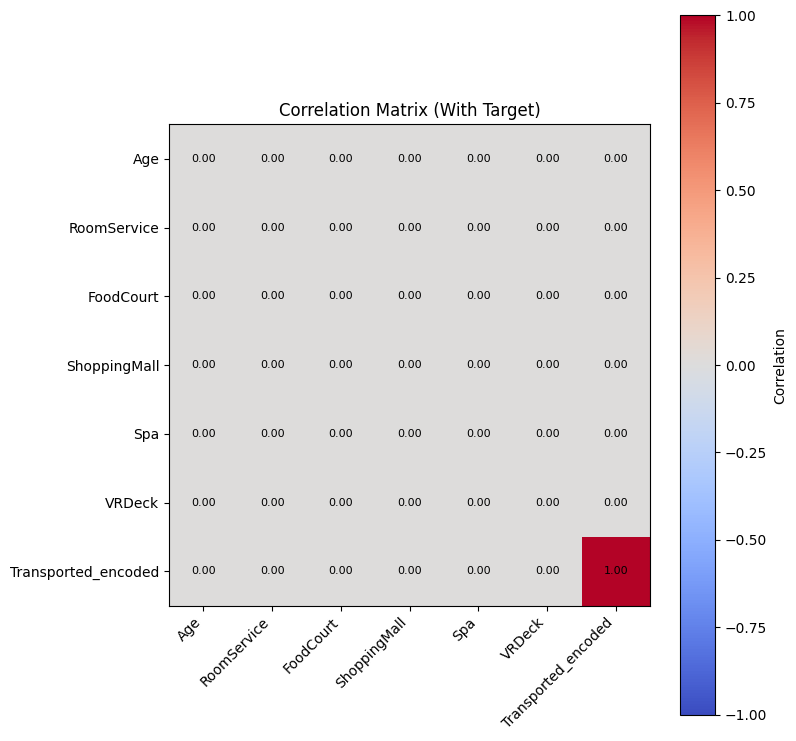

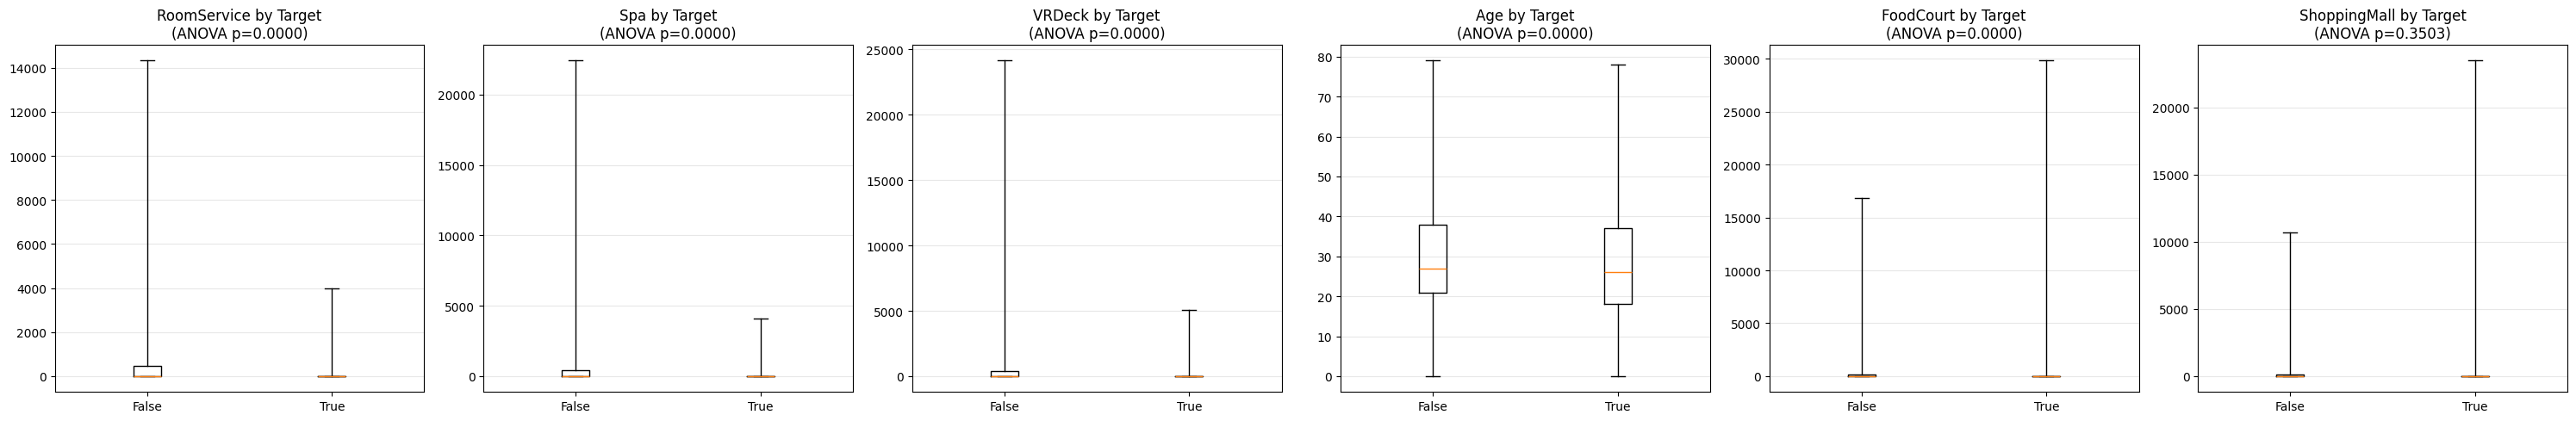

<Figure size 1000x1000 with 0 Axes>

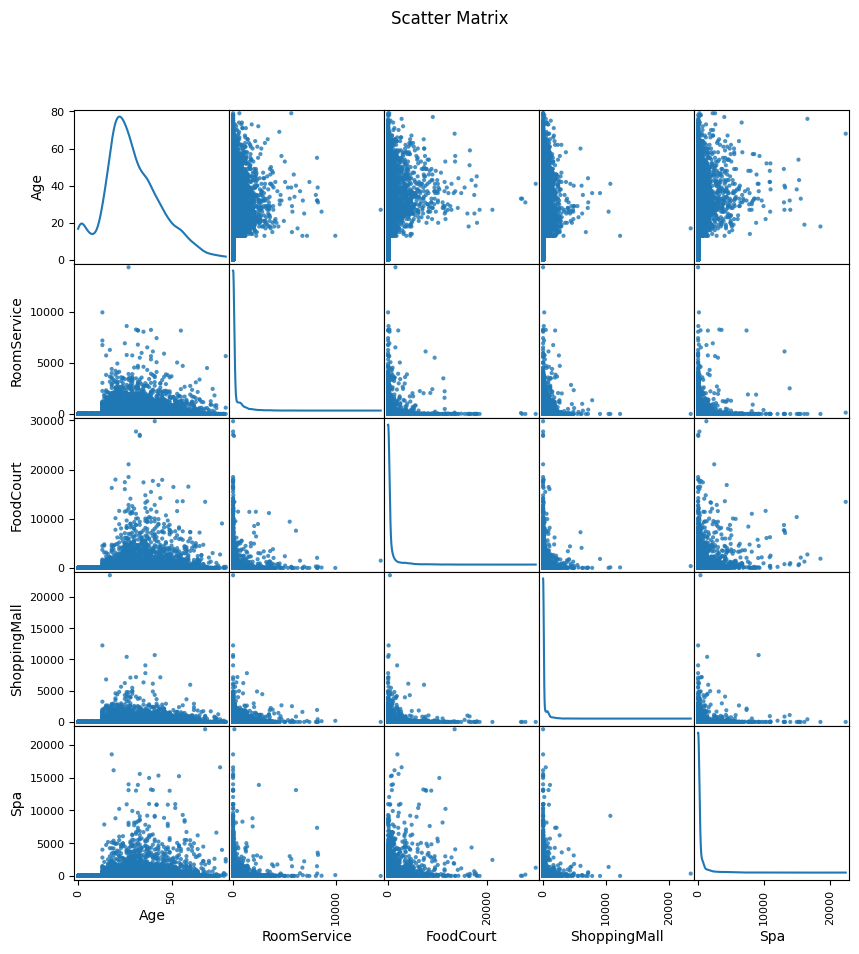

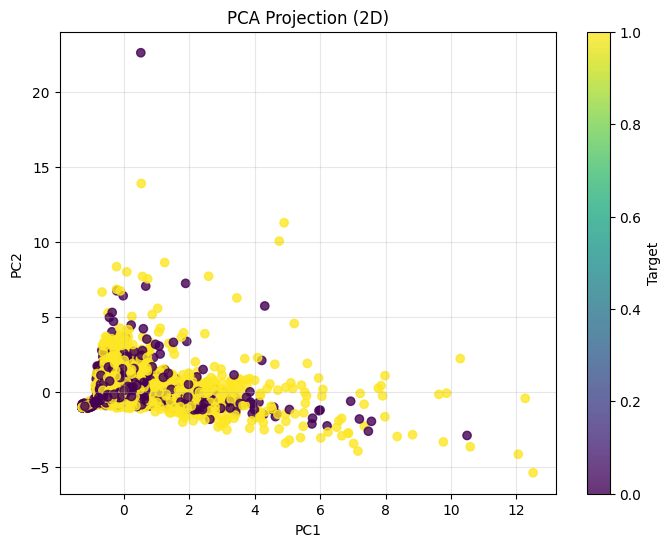

In [6]:
EDAVisualizer(profile, train.drop("PassengerId", "Name")).plot()

## 2. Deterministic feature engineering (safe pre-split)

`PassengerId` and `Cabin` are structured strings that encode real signal —
splitting them is a deterministic parse, not something learned from data, so
it's safe to do before the train/test split. Same for `TotalSpend` and the
`CryoSleep`-vs-spend consistency flag (CryoSleep passengers can't spend money,
so `CryoSleep=True` with `TotalSpend>0` is a real data-quality contradiction
worth flagging as a feature).

In [7]:
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

def engineer(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        .with_columns(
            pl.col("PassengerId").str.split("_").list.get(0).alias("GroupId"),
            pl.col("Cabin").str.split("/").list.get(0).alias("Deck"),
            pl.col("Cabin").str.split("/").list.get(1).cast(pl.Float64, strict=False).alias("CabinNum"),
            pl.col("Cabin").str.split("/").list.get(2).alias("Side"),
            pl.sum_horizontal([pl.col(c).fill_null(0.0) for c in SPEND_COLS]).alias("TotalSpend"),
        )
        .with_columns(
            (pl.col("CryoSleep") & (pl.col("TotalSpend") > 0)).fill_null(False).alias("CryoSleepSpendConflict"),
            pl.col("GroupId").count().over("GroupId").alias("GroupSize"),
        )
        .drop("PassengerId", "Name", "Cabin", "GroupId")
    )

engineered = engineer(train)
print(engineered.shape)
print(f"CryoSleep/spend conflicts flagged: {engineered['CryoSleepSpendConflict'].sum()}")
engineered.select(["GroupSize", "Deck", "CabinNum", "Side", "TotalSpend", "CryoSleepSpendConflict", "Transported"]).head(3)

(8693, 17)
CryoSleep/spend conflicts flagged: 0


GroupSize,Deck,CabinNum,Side,TotalSpend,CryoSleepSpendConflict,Transported
u32,str,f64,str,f64,bool,bool
1,"""B""",0.0,"""P""",0.0,false,false
1,"""F""",0.0,"""S""",736.0,false,true
2,"""A""",0.0,"""S""",10383.0,false,false


## 3. Leakage-safe pipeline

Impute missing numeric/categorical values, one-hot encode categoricals, and
scale numeric columns — all fit on the training split only.

In [8]:
TARGET = "Transported"
CATEGORICAL = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck", "Side", "CryoSleepSpendConflict"]
NUMERIC = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck", "CabinNum", "TotalSpend", "GroupSize"]

model_df = engineered.with_columns(pl.col(TARGET).cast(pl.Int8))

base_preprocessing = [
    {"name": "split", "transformer": "TrainTestSplitter",
     "params": {"test_size": 0.2, "random_state": 42, "stratify": True, "target_column": TARGET}},
    {"name": "impute_numeric", "transformer": "SimpleImputer",
     "params": {"columns": NUMERIC, "strategy": "median"}},
    {"name": "impute_categorical", "transformer": "SimpleImputer",
     "params": {"columns": CATEGORICAL, "strategy": "most_frequent"}},
    {"name": "encode", "transformer": "OneHotEncoder", "params": {"columns": CATEGORICAL, "drop_original": True, "handle_unknown": "ignore"}},
    {"name": "scale", "transformer": "StandardScaler", "params": {"columns": NUMERIC}},
]

## 4. Baseline: Logistic Regression

In [9]:
baseline_config = {
    "preprocessing": base_preprocessing,
    "modeling": {"type": "logistic_regression", "params": {"max_iter": 2000}},
}

baseline_pipeline = SkyulfPipeline(baseline_config)
baseline_metrics = baseline_pipeline.fit(model_df, target_column=TARGET)

## 5. Tuned Random Forest

In [10]:
tuned_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "hyperparameter_tuner",
        "base_model": {"type": "random_forest_classifier"},
        "strategy": "random",
        "metric": "accuracy",
        "n_trials": 15,
        "search_space": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 15, None],
            "min_samples_leaf": [1, 2, 4],
        },
        "cv_folds": 5,
        "random_state": 42,
    },
}

tuned_pipeline = SkyulfPipeline(tuned_config)
tuned_metrics = tuned_pipeline.fit(model_df, target_column=TARGET)

## 6. Voting ensemble

In [11]:
ensemble_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "voting_classifier",
        "params": {
            "base_estimators": ["logistic_regression", "random_forest", "hist_gradient_boosting"],
            "voting": "soft",
        },
    },
}

ensemble_pipeline = SkyulfPipeline(ensemble_config)
ensemble_metrics = ensemble_pipeline.fit(model_df, target_column=TARGET)

## 7. Stacking ensemble

A stacking ensemble trains a meta-model on the out-of-fold predictions of
its base estimators — a different (and often stronger) blending strategy
than voting's simple average.

In [12]:
stacking_config = {
    "preprocessing": base_preprocessing,
    "modeling": {
        "type": "stacking_classifier",
        "params": {
            "base_estimators": ["logistic_regression", "random_forest", "hist_gradient_boosting"],
            "final_estimator": "logistic_regression",
            "cv": 5,
        },
    },
}

stacking_pipeline = SkyulfPipeline(stacking_config)
stacking_metrics = stacking_pipeline.fit(model_df, target_column=TARGET)

## 8. Compare

In [13]:
def summarize(name, metrics):
    m = metrics["modeling"]
    report = m["splits"]["test"] if "splits" in m else m["test"]
    metrics_dict = report.metrics if hasattr(report, "metrics") else report
    acc = metrics_dict.get("accuracy")
    f1 = metrics_dict.get("f1")
    roc_auc = metrics_dict.get("roc_auc")
    print(f"{name:24s} accuracy={acc}  f1={f1}  roc_auc={roc_auc}")
    return {"accuracy": acc, "f1": f1, "roc_auc": roc_auc}


results = {
    "Logistic Regression": summarize("Logistic Regression", baseline_metrics),
    "Tuned Random Forest": summarize("Tuned Random Forest", tuned_metrics),
    "Voting ensemble": summarize("Voting ensemble", ensemble_metrics),
    "Stacking ensemble": summarize("Stacking ensemble", stacking_metrics),
}
best_name = max(results, key=lambda k: results[k]["accuracy"])
print(f"\nBest model by test accuracy: {best_name} ({results[best_name]['accuracy']:.4f})")

Logistic Regression      accuracy=0.7878090856814262  f1=0.791407574901074  roc_auc=0.8813526140626571
Tuned Random Forest      accuracy=0.8004600345025877  f1=0.7995378393991912  roc_auc=0.8968541828706276
Voting ensemble          accuracy=0.8154111558366878  f1=0.8173022196926579  roc_auc=0.9089694545416065
Stacking ensemble        accuracy=0.8125359401955147  f1=0.8168539325842696  roc_auc=0.9122367021698757

Best model by test accuracy: Voting ensemble (0.8154)


## 9. Kaggle submission

Run the real competition `test.csv` through the winning pipeline. The same
deterministic `engineer()` parse is applied first (identical to training),
then `SkyulfPipeline.predict` re-applies the fitted imputers/encoders/scaler
automatically.

In [14]:
test_raw = pl.read_csv("data/spaceship_titanic/test.csv", infer_schema_length=None)
test_ids = test_raw["PassengerId"]
test_engineered = engineer(test_raw)

pipelines = {
    "Logistic Regression": baseline_pipeline,
    "Tuned Random Forest": tuned_pipeline,
    "Voting ensemble": ensemble_pipeline,
    "Stacking ensemble": stacking_pipeline,
}
best_pipeline = pipelines[best_name]
predictions = best_pipeline.predict(test_engineered)
pred_bool = np.asarray(predictions).astype(bool).reshape(-1)

submission = pl.DataFrame({"PassengerId": test_ids, "Transported": pred_bool})
submission.write_csv("spaceship_titanic_submission.csv")
print(submission.shape)
submission.head()

(4277, 2)


PassengerId,Transported
str,bool
"""0013_01""",true
"""0018_01""",false
"""0019_01""",true
"""0021_01""",true
"""0023_01""",true


## Takeaways

- Parsing structured string columns (`PassengerId`, `Cabin`) into real
  features before the split is a deterministic, leakage-safe transform — it
  doesn't learn anything from the data, unlike imputation/encoding/scaling
  which must happen after the split.
- The `CryoSleep`-vs-`TotalSpend` consistency check is a good example of
  domain-knowledge feature engineering: it encodes a real-world constraint
  (sleeping passengers can't spend money) as a signal rather than silently
  ignoring the contradiction. On this particular (clean, synthetic) dataset
  it happens to flag zero conflicts — a useful reminder that not every
  engineered feature turns out informative on every dataset, and that's fine.
- Measured above: the best of four models (linear, tuned tree ensemble,
  voting, and stacking) is picked by computed test accuracy, not asserted —
  voting/stacking ensembles are strong defaults when you don't know in
  advance which inductive bias fits best.
- `spaceship_titanic_submission.csv` was generated directly from the real
  competition `test.csv` via `pipeline.predict(...)`, ready to submit to
  Kaggle as-is.